# 02 – EDA: CMS Medicare Geographic Variation (2014–2024)
**Input:** `data/clean/county.csv`, `data/clean/state.csv`, `data/clean/national.csv`
**Output:** Exploratory analysis of national, state and county data in `notebooks/analysis/`

## 1. Importing libraries

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Folder where every chart is saved, so the Quarto report can use them
FIG_DIR = "../report/figures"
os.makedirs(FIG_DIR, exist_ok=True)

# Big numbers: commas, no decimals (12,433). Small numbers: 2 decimals (0.67, 18.20)
pd.set_option(
    "display.float_format",
    lambda x: f"{x:,.0f}" if abs(x) >= 100 else f"{x:.2f}"
)

## 2. Converting cleaned csv files into dataframe
and briefly checking if it is working

In [2]:
national_df = pd.read_csv(
    "../data/clean/national_clean.csv",
    dtype={"fips": str}
)

state_df = pd.read_csv(
    "../data/clean/state_clean.csv",
    dtype={"fips": str}
)

county_df = pd.read_csv(
    "../data/clean/county_clean.csv",
    dtype={"fips": str}
)

In [3]:
# Checking the top 2 rows of each dataframe
display (national_df.head(2))
display (state_df.head(2))
display (county_df.head(2))

,year,name,fips,benes_total,benes_om,ma_rate_pct,avg_age,female_pct,medicaid_pct,spend_pc_actual,spend_pc_std,ip_spend_pc_std,ip_share_pct,ip_stays_per_1000,ip_users_pct,readmit_rate_pct,ed_visits_per_1000
0,2014,National,NaN,"56,767,775","33,462,969",32.13,71.00,55.05,21.48,"9,767","9,191","2,620",28.51,282,17.50,18.08,671
1,2015,National,NaN,"58,294,174","33,551,396",33.92,71.00,54.94,20.95,"9,959","9,455","2,644",27.96,279,17.36,17.97,683


,year,name,fips,benes_total,benes_om,ma_rate_pct,avg_age,female_pct,medicaid_pct,spend_pc_actual,spend_pc_std,ip_spend_pc_std,ip_share_pct,ip_stays_per_1000,ip_users_pct,readmit_rate_pct,ed_visits_per_1000
0,2014,AK,02,"84,573","71,383",0.66,70.00,50.32,23.81,"8,602","6,524","2,114",32.40,195,13.60,13.71,555
1,2014,AL,01,"994,352","674,129",24.99,70.00,55.83,20.95,"8,655","9,365","2,657",28.37,295,18.58,17.17,685


,year,name,fips,benes_total,benes_om,ma_rate_pct,avg_age,female_pct,medicaid_pct,spend_pc_actual,spend_pc_std,ip_spend_pc_std,ip_share_pct,ip_stays_per_1000,ip_users_pct,readmit_rate_pct,ed_visits_per_1000,rucc_code,rural_urban
0,2014,AK-Aleutians East,02013,168,117,NaN,71.00,43.59,23.08,"6,076","4,577","1,366",29.84,154,11.11,NaN,197,9.00,Rural
1,2014,AK-Aleutians West,02016,231,136,0.00,69.00,47.79,27.21,"13,251","9,712","3,305",34.03,206,16.91,NaN,199,9.00,Rural


## 3. Medicare Spending Across Places, 2014–2024
Missing spending values of some counties are automatically excluded

### 3a. National spending by year, 2014–2024

In [4]:
# Calculate the unweighted mean and median across places
state_summary = state_df.groupby("year")["spend_pc_std"].agg(
    ["mean", "median"]
).reset_index()

county_summary = county_df.groupby("year")["spend_pc_std"].agg(
    ["mean", "median"]
).reset_index()

# Keep rows with both spending and Original Medicare counts available
state_weighted = state_df.dropna(
    subset=["spend_pc_std", "benes_om"]
).copy()

county_weighted = county_df.dropna(
    subset=["spend_pc_std", "benes_om"]
).copy()

# Multiply spending per beneficiary by the Original Medicare count
state_weighted["weighted_spending"] = (
    state_weighted["spend_pc_std"] * state_weighted["benes_om"]
)

county_weighted["weighted_spending"] = (
    county_weighted["spend_pc_std"] * county_weighted["benes_om"]
)

# Sum the weighted spending and matching beneficiary counts by year
state_totals = state_weighted.groupby("year")[
    ["weighted_spending", "benes_om"]
].sum()

county_totals = county_weighted.groupby("year")[
    ["weighted_spending", "benes_om"]
].sum()

# Calculate the weighted mean: larger OM populations receive more weight
state_totals["weighted_mean"] = (
    state_totals["weighted_spending"] / state_totals["benes_om"]
)

county_totals["weighted_mean"] = (
    county_totals["weighted_spending"] / county_totals["benes_om"]
)

# Add the weighted means to the summaries used for plotting
state_summary = state_summary.merge(
    state_totals[["weighted_mean"]].reset_index(), on="year"
)

county_summary = county_summary.merge(
    county_totals[["weighted_mean"]].reset_index(), on="year"
)



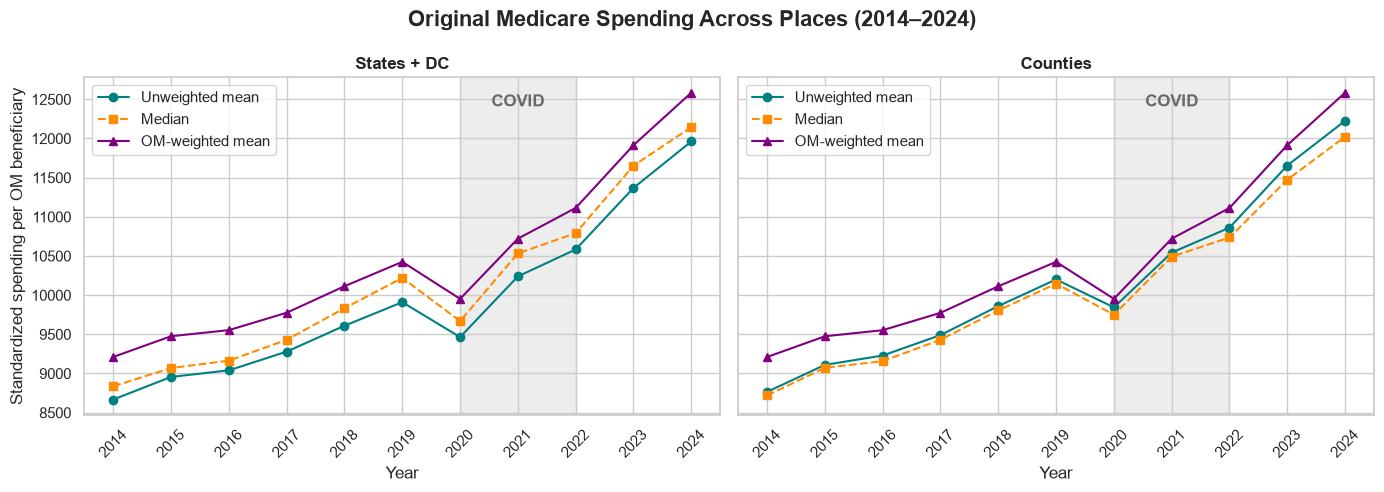

In [5]:
# Visualization

sns.set_theme(style="whitegrid")


fig, axes = plt.subplots(
    1, 2, figsize=(14, 5), sharex=True, sharey=True
)

for ax, summary, title in [
    (axes[0], state_summary, "States + DC"),
    (axes[1], county_summary, "Counties")
]:
    # Each place receives equal weight in the unweighted mean
    ax.plot(
        summary["year"], summary["mean"],
        marker="o", color="teal", label="Unweighted mean"
    )

    # Median spending across places
    ax.plot(
        summary["year"], summary["median"],
        marker="s", linestyle="--",
        color="darkorange", label="Median"
    )

    # Places with more Original Medicare beneficiaries receive more weight
    ax.plot(
        summary["year"], summary["weighted_mean"],
        marker="^", color="purple", label="OM-weighted mean"
    )

    # Highlight 2020–2022 and label the shaded area
    ax.axvspan(
        2020, 2022, color="lightgray", alpha=0.4, zorder=0
    )
    ax.text(
        2021, 0.95, "COVID",
        transform=ax.get_xaxis_transform(),
        ha="center", va="top",
        color="dimgray", fontweight="bold"
    )

    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Year")
    ax.set_xticks(summary["year"])
    ax.tick_params(axis="x", rotation=45)
    ax.legend(loc="upper left")

axes[0].set_ylabel("Standardized spending per OM beneficiary")

fig.suptitle(
    "Original Medicare Spending Across Places (2014–2024)",
    fontsize=16, fontweight="bold"
)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig1_spending_trend.png", dpi=150, bbox_inches="tight")
plt.show()


### Interpretation
1. **Original Medicare (OM) standardized spending per beneficiary increased overall between 2014 and 2024** at both the state and county levels. This upward trend was interrupted by a decline in 2020, followed by increases from 2021 onward. The decline coincides with the COVID-19 pandemic, highlighted by the gray shading, although the graph alone cannot establish its cause.

2. **Accounting for beneficiary population changes the spending picture.** The OM-weighted mean remains above the unweighted mean in both panels, indicating that places with larger Original Medicare populations tend to have higher spending per beneficiary. The weighted means also closely align across the state and county panels, consistent with both geographic levels summarizing largely the same underlying population.

3. **The unweighted mean and median reveal additional differences between the geographic levels.** Across states, the mean remains below the median, suggesting that lower-spending states pull the average downward. Across counties, the mean is slightly above the median, suggesting that higher-spending counties pull the average upward. 

**Notes:** Unweighted measures give each place equal weight, while the weighted mean uses Original Medicare beneficiary counts. Missing spending is excluded, and weighted calculations also require valid beneficiary counts. Spending is standardized for geographic payment differences but is not adjusted for inflation, so the increase over time should not be interpreted entirely as increased use of care.

### 3b. Geographic Variation in OM Spending by State (2024)

Map standardized spending per Original Medicare beneficiary across states and DC

In [17]:
# Select states for 2024
state_map = state_df[state_df["year"] == 2024].copy()

# Use state abbreviations to locate each state on map
fig = px.choropleth(
    state_map,
    locations="name",
    locationmode="USA-states",
    scope="usa",
    color="spend_pc_std",
    color_continuous_scale="YlOrRd",
    hover_name="name",
    hover_data={
        "spend_pc_std": ":,.0f",
        "benes_om": ":,.0f"
    },
    labels={
        "spend_pc_std": "Spending per OM beneficiary",
        "benes_om": "OM beneficiaries"
    },
    title="Standardized Original Medicare Spending by State (In 2024)"
)

fig.update_layout(
    height=600,
    margin=dict(l=20, r=20, t=60, b=20)
)

fig.write_image(f"{FIG_DIR}/fig6_state_map_2024.png", width=1000, height=600, scale=2)
fig.show()

### Interpretation

1. Standardized spending per Original Medicare beneficiary varies substantially across states. Florida has the highest spending at $14,680, while Hawaii has the lowest at $8,622—a difference of $6,058 per beneficiary.

2. **Higher spending is concentrated in several southern states**, including Florida, Oklahoma, Mississippi, Louisiana, and Texas. Lower spending appears in Hawaii, Alaska, Oregon, Vermont, and Montana. However, the map also shows variation within broad regions, so geography alone does not explain the differences.

3. Because spending is standardized for geographic payment-rate differences, the darker shades cannot simply be attributed to higher local payment rates. Differences may reflect service use, beneficiary health needs, and other factors that this map does not separate. Higher spending therefore does not, by itself, indicate better care or greater inefficiency.

### 3c. Change in spending by state, 2014–2024
Percentage growth in standardized spending per OM beneficiary for each state, compared with national growth. Comparing states with the national figure sidesteps inflation, since all states face the same price changes.

National growth 2014–2024: 36.6%


year,2014,2024,pct_change,vs_national
name,,,,
MI,"9,767","12,079",23.70,-12.90
OH,"9,754","12,145",24.50,-12.10
DC,"9,673","12,133",25.40,-11.10
PA,"9,485","12,223",28.90,-7.70
LA,"10,997","14,247",29.60,-7.00


year,2014,2024,pct_change,vs_national
name,,,,
AZ,"8,302","12,251",47.60,11.00
MN,"7,944","11,764",48.10,11.50
OK,"9,606","14,318",49.10,12.50
WY,"7,152","10,805",51.10,14.50
CA,"8,649","13,254",53.20,16.70


Correlation between 2014 spending and growth: -0.46


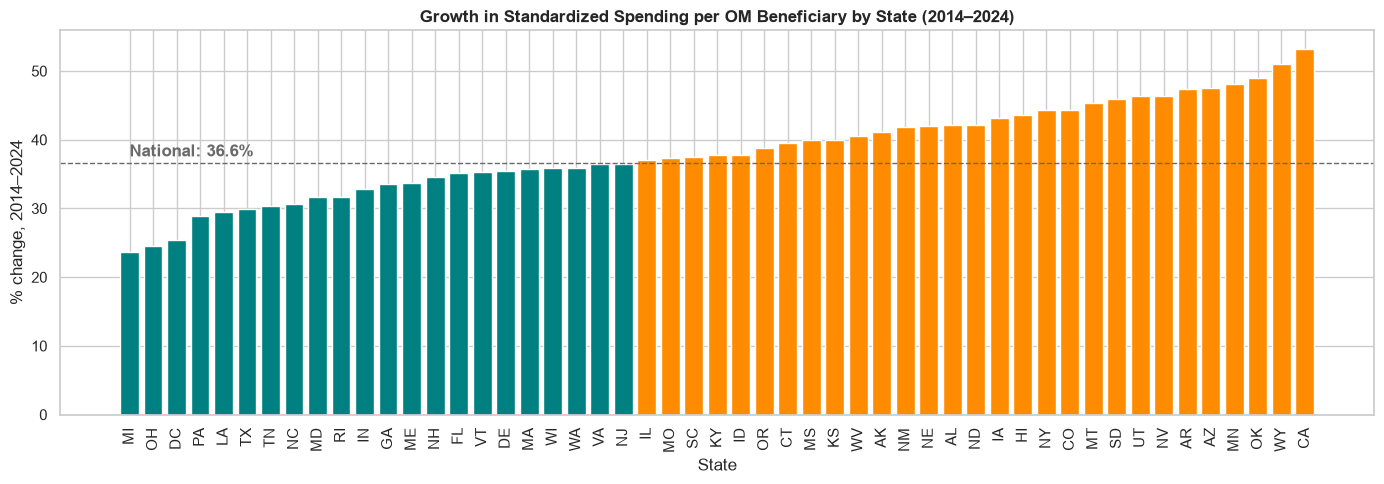

In [6]:
start, end = 2014, 2024

# One row per state, one column per year
growth = state_df.pivot(index="name", columns="year", values="spend_pc_std")[[start, end]].copy()

# % change for each state
growth["pct_change"] = (growth[end] / growth[start] - 1) * 100

# National % change, used as the benchmark
nat = national_df.set_index("year")["spend_pc_std"]
national_growth = (nat[end] / nat[start] - 1) * 100

# How far above or below national growth each state is (percentage points)
growth["vs_national"] = growth["pct_change"] - national_growth
growth = growth.sort_values("pct_change")

print(f"National growth {start}–{end}: {national_growth:.1f}%")
display(growth.round(1).head(5))   # slowest growth
display(growth.round(1).tail(5))   # fastest growth

# Do states that started low grow faster? (negative = yes)
print("Correlation between 2014 spending and growth:",
      round(growth[start].corr(growth["pct_change"]), 2))

# Visualization
fig, ax = plt.subplots(figsize=(14, 5))
colors = ["darkorange" if v > national_growth else "teal" for v in growth["pct_change"]]
ax.bar(growth.index, growth["pct_change"], color=colors)
ax.axhline(national_growth, color="dimgray", linestyle="--", linewidth=1)
ax.text(0, national_growth + 1, f"National: {national_growth:.1f}%",
        color="dimgray", fontweight="bold")

ax.set_title(f"Growth in Standardized Spending per OM Beneficiary by State ({start}–{end})",
             fontweight="bold")
ax.set_xlabel("State")
ax.set_ylabel(f"% change, {start}–{end}")
ax.tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig2_state_growth.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
spread = state_df.groupby("year")["spend_pc_std"].agg(["mean", "std", "min", "max"])
spread["gap_max_min"] = spread["max"] - spread["min"]     # highest minus lowest state
spread["cv"] = spread["std"] / spread["mean"]             # spread relative to the average
display(spread.round(2))

,mean,std,min,max,gap_max_min,cv
year,,,,,,
2014,"8,668","1,111","6,005","10,997","4,992",0.13
2015,"8,956","1,103","6,266","11,266","5,000",0.12
2016,"9,040","1,089","6,441","11,400","4,959",0.12
2017,"9,279","1,094","6,675","11,539","4,864",0.12
2018,"9,610","1,130","6,914","11,949","5,035",0.12
2019,"9,910","1,192","7,128","12,204","5,076",0.12
2020,"9,464","1,215","6,659","12,095","5,436",0.13
2021,"10,240","1,185","7,313","12,477","5,164",0.12
2022,"10,583","1,246","7,651","13,055","5,404",0.12


In [8]:
# Sort: by year, then by spending from highest to lowest within each year
sorted_states = state_df.sort_values(["year", "spend_pc_std"], ascending=[True, False])

# First row of each year = highest spender; last row = lowest
highest = sorted_states.groupby("year").head(1)
lowest = sorted_states.groupby("year").tail(1)

# Put them side by side, matched on year
top_bottom = pd.merge(
    highest[["year", "name", "spend_pc_std"]],
    lowest[["year", "name", "spend_pc_std"]],
    on="year",
    suffixes=("_high", "_low")
)


# Readable column names
top_bottom = top_bottom.rename(columns={
    "year": "Year",
    "name_high": "Highest state",
    "spend_pc_std_high": "Highest ($)",
    "name_low": "Lowest state",
    "spend_pc_std_low": "Lowest ($)"
})

display(top_bottom)

,Year,Highest state,Highest ($),Lowest state,Lowest ($)
0,2014,LA,"10,997",HI,"6,005"
1,2015,LA,"11,266",HI,"6,266"
2,2016,LA,"11,400",HI,"6,441"
3,2017,LA,"11,539",HI,"6,675"
4,2018,LA,"11,949",HI,"6,914"
5,2019,LA,"12,204",HI,"7,128"
6,2020,LA,"12,095",HI,"6,659"
7,2021,LA,"12,477",HI,"7,313"
8,2022,LA,"13,055",HI,"7,651"
9,2023,LA,"13,805",HI,"8,203"


### Interpretation
1. **The highest and lowest spenders were very stable.** Louisiana had the highest standardized spending per OM beneficiary in every year from 2014 to 2023, with Florida taking the top position in 2024. Hawaii had the lowest spending in all 11 years.

2. **Spending grew in every state, but at very different rates.** Nationally, standardized spending per OM beneficiary rose 36.6% between 2014 and 2024. Growth ranged from 23.7% in Michigan to 53.2% in California.

3. **States that started with lower spending tended to grow faster** (correlation between 2014 spending and growth = −0.46). For example, Wyoming and Minnesota started below average and grew by about 50%, while Louisiana, the highest spender for most of the period, grew by 30%. This is a moderate tendency rather than a rule.

4. **As a result, states became slightly more similar relative to the average, even though the dollar gap widened.** The difference between the highest- and lowest-spending state grew from $4,992 to $6,058, but the coefficient of variation (spread relative to the mean) fell from 0.13 to 0.11. In other words, spending rose everywhere, and the gap grew in dollars but not as a share of typical spending.

**Note:** Percentages are calculated from nominal dollars. Because every state faces the same inflation, comparisons between states are fair, but the national 36.6% should not be read as a 36.6% increase in care.

## 4. Spending and Hospital Use (2024)
Do places that spend more per Original Medicare beneficiary also use more hospital care?

### 4a. Total spending and hospital use
Plotting 2024 county spending against inpatient stays, readmissions and ED visits

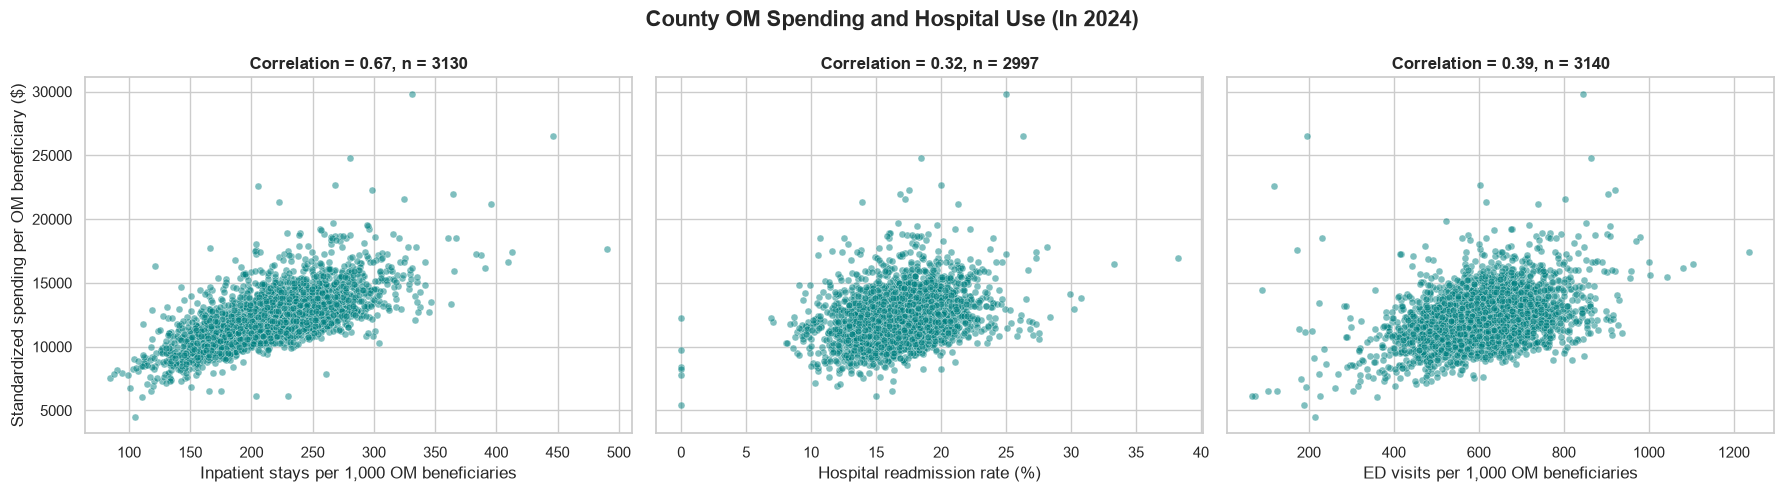

,Hospital-use measure,Correlation,Counties included
0,"Inpatient stays per 1,000 OM beneficiaries",0.67,3130
1,Hospital readmission rate (%),0.32,2997
2,"ED visits per 1,000 OM beneficiaries",0.39,3140


In [9]:
# Select 2024 and exclude unknown county locations
county_2024 = county_df[county_df["year"] == 2024].copy()

county_2024 = county_2024[
    ~county_2024["name"].str.endswith("-UNKNOWN", na=False)
]

# Define hospital-use measures and labels
measures = [
    ("ip_stays_per_1000", "Inpatient stays per 1,000 OM beneficiaries"),
    ("readmit_rate_pct", "Hospital readmission rate (%)"),
    ("ed_visits_per_1000", "ED visits per 1,000 OM beneficiaries")
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
correlation_rows = []

for ax, (variable, label) in zip(axes, measures):

 # Exclude missing values only for the current comparison
    pairs = county_2024.dropna(subset=["spend_pc_std", variable])

# Calculate correlation
    correlation = pairs["spend_pc_std"].corr(pairs[variable])

# Visualization
    sns.scatterplot(
        data=pairs,
        x=variable,
        y="spend_pc_std",
        color="teal",
        alpha=0.5,
        s=25,
        ax=ax
    )

    ax.set_title(
        f"Correlation = {correlation:.2f}, n = {len(pairs)}",
        fontweight="bold"
    )
    ax.set_xlabel(label)
    ax.set_ylabel("")

 # Save the correlation and count of counties
    correlation_rows.append({
        "Hospital-use measure": label,
        "Correlation": correlation,
        "Counties included": len(pairs)
    })

axes[0].set_ylabel("Standardized spending per OM beneficiary ($)")

fig.suptitle(
    "County OM Spending and Hospital Use (In 2024)",
    fontsize=16, fontweight="bold"
)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig3_spending_vs_hospital_use.png", dpi=150, bbox_inches="tight")
plt.show()

display(pd.DataFrame(correlation_rows).round(2))

### Interpretation
1. **Counties with more inpatient stays have higher spending** (r = 0.67, 3,130 counties), the clearest relationship of the three. Because total spending includes inpatient payments, part of this is automatic; we test this directly below.

2. **The links with ED visits (r = 0.39) and readmissions (r = 0.32) are weaker**, with much more scatter. If higher spending bought better hospital care, readmissions would be lower in high-spending counties; instead the correlation is positive.

3. **Counts differ by panel** (3,130 / 2,997 / 3,140) because each comparison drops counties missing either value.


### 4b. Removing hospital spending: Does the relationship hold without hospital spending?
Total spending includes inpatient spending, so part of the link with inpatient stays is automatic. We subtract inpatient spending and repeat the test for states and counties.

In [10]:
# Select 2024 for states (counties were already selected above as county_2024)
state_2024 = state_df[state_df["year"] == 2024].copy()

# Non-hospital spending = total spending minus inpatient spending
state_2024["non_ip_spend_pc_std"] = state_2024["spend_pc_std"] - state_2024["ip_spend_pc_std"]
county_2024["non_ip_spend_pc_std"] = county_2024["spend_pc_std"] - county_2024["ip_spend_pc_std"]

rows = []
for level, data in [("States", state_2024), ("Counties", county_2024)]:
    # Keep places that have all three values
    pairs = data.dropna(subset=["spend_pc_std", "non_ip_spend_pc_std", "ip_stays_per_1000"])

    rows.append({
        "Level": level,
        "r: total spending": pairs["spend_pc_std"].corr(pairs["ip_stays_per_1000"]),
        "r: non-hospital spending": pairs["non_ip_spend_pc_std"].corr(pairs["ip_stays_per_1000"]),
        "Spearman: total spending": pairs["spend_pc_std"].corr(pairs["ip_stays_per_1000"], method="spearman"),
        "Spearman: non-hospital spending": pairs["non_ip_spend_pc_std"].corr(pairs["ip_stays_per_1000"], method="spearman"),
        "n": len(pairs),
    })

corr_table = pd.DataFrame(rows)
display(corr_table.round(2))

,Level,r: total spending,r: non-hospital spending,Spearman: total spending,Spearman: non-hospital spending,n
0,States,0.81,0.69,0.78,0.65,51
1,Counties,0.67,0.51,0.67,0.51,3130


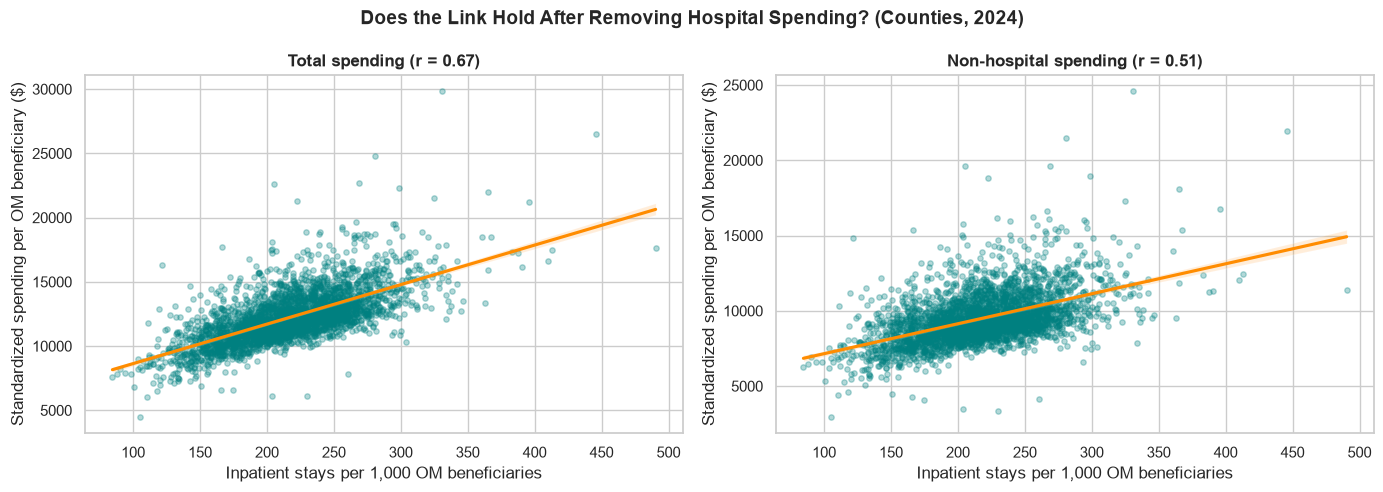

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

for ax, y, title in [
    (axes[0], "spend_pc_std", "Total spending"),
    (axes[1], "non_ip_spend_pc_std", "Non-hospital spending"),
]:
    pairs = county_2024.dropna(subset=[y, "ip_stays_per_1000"])
    r = pairs[y].corr(pairs["ip_stays_per_1000"])

    # Scatter plus a straight trend line
    sns.regplot(
        data=pairs, x="ip_stays_per_1000", y=y, ax=ax,
        scatter_kws={"alpha": 0.3, "s": 15, "color": "teal"},
        line_kws={"color": "darkorange"}
    )

    ax.set_title(f"{title} (r = {r:.2f})", fontweight="bold")
    ax.set_xlabel("Inpatient stays per 1,000 OM beneficiaries")
    ax.set_ylabel("Standardized spending per OM beneficiary ($)")

fig.suptitle("Does the Link Hold After Removing Hospital Spending? (Counties, 2024)",
             fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig4_nonip_test.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretation

1. **The link holds after removing hospital spending.** Total spending includes inpatient spending, so part of the original correlation was automatic. With inpatient spending removed, the correlation with inpatient stays falls from 0.67 to 0.51 (counties) and from 0.81 to 0.69 (states), but stays clearly positive. Places that spend more on care outside the hospital also use more hospital care.

2. **It is stronger for states** because averaging over many counties smooths out noise

3. **It is not driven by outliers**: Spearman rank correlations are similar (0.51 counties, 0.65 states).

### Caveats
1. Correlation does not show causation. 
2. We could not adjust for how sick patients are, as the 2024 file has no risk score. 
3. Results describe places, not individual patients. Places with higher spending have more hospital stays on average; this does not mean individual high-cost patients are admitted more often.
4. Single year (2024) and Original Medicare only. 
4. We tested inpatient stays only, since ED and readmission costs do not separate cleanly from non-hospital spending.

## 5. Forecasting and Residual Plots
Comparing the accuracy of 2-years and 3-years moving average forecast models

Historical forecasts and actual spending:


,year,spend_pc_std,forecast_2yr,forecast_3yr
3,2017,"9,753","9,494","9,393"
4,2018,"10,093","9,643","9,580"
5,2019,"10,404","9,923","9,793"
6,2020,"9,931","10,248","10,083"
7,2021,"10,696","10,168","10,143"
8,2022,"11,087","10,314","10,344"
9,2023,"11,886","10,892","10,571"
10,2024,"12,553","11,486","11,223"


Historical forecast accuracy:


,Method,MAD,MAPE (%)
0,forecast_2yr,609,5.46
1,forecast_3yr,697,6.21


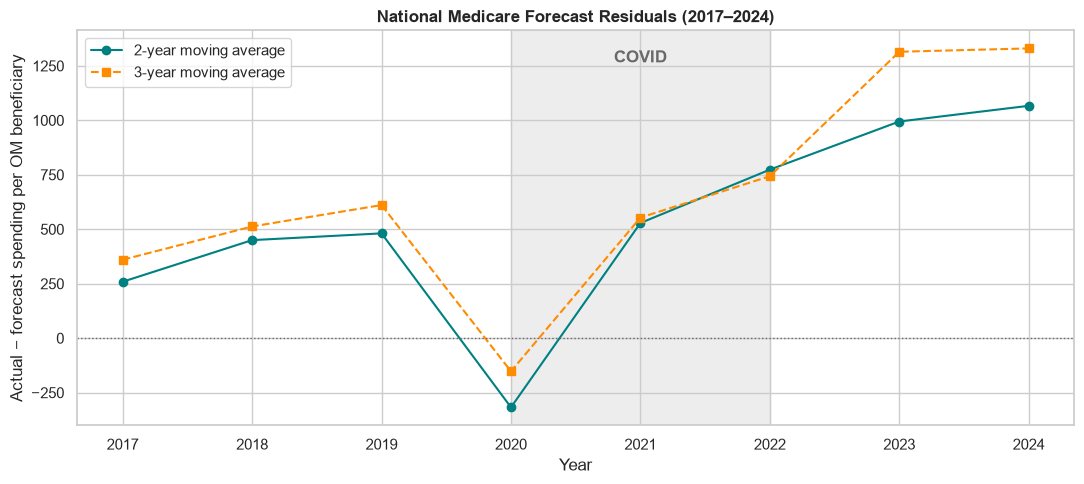

In [12]:
# Sort national spending by year
forecast_df = national_df[
    ["year", "spend_pc_std"]
].sort_values("year").copy()

# Predict each year using the previous 2 or 3 years
forecast_df["forecast_2yr"] = (
    forecast_df["spend_pc_std"].shift(1).rolling(2).mean()
)

forecast_df["forecast_3yr"] = (
    forecast_df["spend_pc_std"].shift(1).rolling(3).mean()
)

# Compare both methods using the same years (2017–2024)
comparison = forecast_df.dropna(
    subset=["spend_pc_std", "forecast_2yr", "forecast_3yr"]
).copy()

accuracy_rows = []

for method in ["forecast_2yr", "forecast_3yr"]:
    # Calculate the absolute difference between actual and forecast spending
    absolute_error = abs(
        comparison["spend_pc_std"] - comparison[method]
    )

    # Mean absolute error
    mad = absolute_error.mean()

    # Mean absolute percentage error
    mape = (
        absolute_error / comparison["spend_pc_std"] * 100
    ).mean()

    accuracy_rows.append({
        "Method": method,
        "MAD": mad,
        "MAPE (%)": mape
    })

print("Historical forecasts and actual spending:")
display(comparison.round(2))

print("Historical forecast accuracy:")
display(pd.DataFrame(accuracy_rows).round(2))

# Calculate forecast residuals using the same comparison years
residual_df = comparison.copy()

residual_df["residual_2yr"] = (
    residual_df["spend_pc_std"] - residual_df["forecast_2yr"]
)

residual_df["residual_3yr"] = (
    residual_df["spend_pc_std"] - residual_df["forecast_3yr"]
)

fig, ax = plt.subplots(figsize=(11, 5))

# Visualization
ax.plot(
    residual_df["year"], residual_df["residual_2yr"],
    marker="o", color="teal", label="2-year moving average"
)

ax.plot(
    residual_df["year"], residual_df["residual_3yr"],
    marker="s", linestyle="--",
    color="darkorange", label="3-year moving average"
)

# Zero represents a forecast that exactly matches actual spending
ax.axhline(
    0, color="dimgray", linestyle=":", linewidth=1
)

# Highlight the selected COVID period
ax.axvspan(
    2020, 2022, color="lightgray", alpha=0.4, zorder=0
)
ax.text(
    2021, 0.95, "COVID",
    transform=ax.get_xaxis_transform(),
    ha="center", va="top",
    color="dimgray", fontweight="bold"
)
ax.set_title(
    "National Medicare Forecast Residuals (2017–2024)",
    fontweight="bold"
)
ax.set_xlabel("Year")
ax.set_ylabel("Actual − forecast spending per OM beneficiary")
ax.set_xticks(residual_df["year"])
ax.legend()

plt.tight_layout()
plt.show()

### Interpretation
1. The **2-year moving average performed better overall** during 2017–2024. Its MAD was 608.81 per beneficiary, compared with $697.17 for the 3-year method. Its MAPE was also lower.

2. Both methods generally underestimated spending as it increased over time. In 2024, actual standardized spending was $12,553 per OM beneficiary while the 2-year forecast was 11,486.50 and the 3-year forecast was $11,223. Moving averages lag behind a rising trend because they rely on earlier, lower spending values.

3. The pattern reversed in 2020, when spending declined and both methods overestimated it. This illustrates their limited ability to anticipate sudden changes. Although the 2-year method was more accurate overall, it was not better in every individual year.


## 6. Hospital Use in Urban and Rural Counties: 2014–2019 vs 2023–2024

Compare average hospital use across urban and rural counties. The comparison excludes the selected pandemic disruption period, 2020–2022.

In [13]:
# Keep 2014–2019 and 2023–2024, and counties with an Urban/Rural label
county_compare = county_df[
    ((county_df["year"] <= 2019) | (county_df["year"] >= 2023)) &
    county_df["rural_urban"].isin(["Urban", "Rural"])
].copy()

# Label each row's period
county_compare["period"] = county_compare["year"].apply(
    lambda year: "Pre: 2014–2019" if year <= 2019 else "Post: 2023–2024"
)

# Spending is now included alongside the three hospital-use measures
measures = [
    ("spend_pc_std", "Standardized spending per beneficiary ($)"),
    ("ip_stays_per_1000", "Inpatient stays per 1,000"),
    ("readmit_rate_pct", "Readmission rate (%)"),
    ("ed_visits_per_1000", "ED visits per 1,000"),
]

In [14]:
rows = []
for variable, label in measures:
    # Keep rows that have both the measure and the beneficiary count
    data = county_compare.dropna(subset=[variable, "benes_om"]).copy()

    # Weight: number of beneficiaries, except readmissions, which are a share of hospital stays
    if variable == "readmit_rate_pct":
        data = data.dropna(subset=["ip_stays_per_1000"])
        data["weight"] = data["ip_stays_per_1000"] * data["benes_om"] / 1000
    else:
        data["weight"] = data["benes_om"]

    # Step 1: value × weight
    data["weighted_value"] = data[variable] * data["weight"]

    # Step 2: sum values and weights for each county type and period
    totals = data.groupby(["rural_urban", "period"])[["weighted_value", "weight"]].sum()

    # Step 3: divide
    totals["weighted_mean"] = totals["weighted_value"] / totals["weight"]

    # Simple average too, for comparison
    totals["unweighted_mean"] = data.groupby(["rural_urban", "period"])[variable].mean()

    totals["measure"] = label
    rows.append(totals[["measure", "weighted_mean", "unweighted_mean"]].reset_index())

rural_urban_summary = pd.concat(rows)

# Readable layout: one row per measure, one column per period and county type
readable = rural_urban_summary.pivot(
    index="measure",
    columns=["period", "rural_urban"],
    values="weighted_mean"
)
readable = readable[[("Pre: 2014–2019", "Urban"), ("Pre: 2014–2019", "Rural"),
                     ("Post: 2023–2024", "Urban"), ("Post: 2023–2024", "Rural")]]
readable = readable.loc[[label for _, label in measures]]   # keep measures in the original order
display(readable.round(1))

# Weighted vs unweighted spending (the comparison the interpretation refers to)
spending = rural_urban_summary[rural_urban_summary["measure"] == measures[0][1]]
display(spending[["rural_urban", "period", "weighted_mean", "unweighted_mean"]].round(0))

period                                    Pre: 2014–2019        \
rural_urban                                        Urban Rural   
measure                                                          
Standardized spending per beneficiary ($)          9,896 9,251   
Inpatient stays per 1,000                            275   265   
Readmission rate (%)                               18.30 17.00   
ED visits per 1,000                                  662   725   

period                                    Post: 2023–2024         
rural_urban                                         Urban  Rural  
measure                                                           
Standardized spending per beneficiary ($)          12,433 11,519  
Inpatient stays per 1,000                             228    209  
Readmission rate (%)                                18.20  16.80  
ED visits per 1,000                                   579    622

,rural_urban,period,weighted_mean,unweighted_mean
0,Rural,Post: 2023–2024,"11,519","11,930"
1,Rural,Pre: 2014–2019,"9,251","9,377"
2,Urban,Post: 2023–2024,"12,433","11,958"
3,Urban,Pre: 2014–2019,"9,897","9,549"


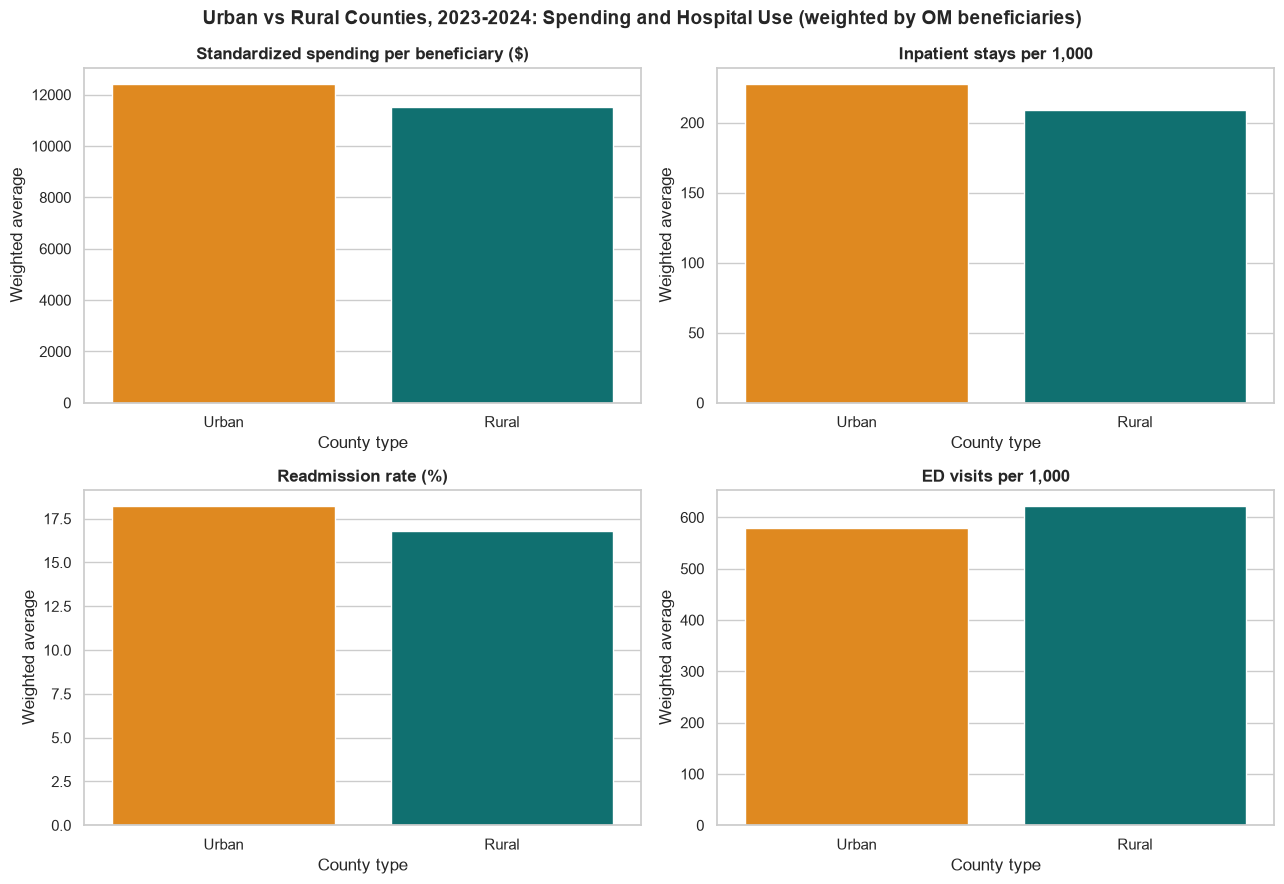

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, (variable, label) in zip(axes.flatten(), measures):
    plot_data = rural_urban_summary[
        (rural_urban_summary["measure"] == label) &
        (rural_urban_summary["period"] == "Post: 2023–2024")
    ]

    sns.barplot(
        data=plot_data, x="rural_urban", y="weighted_mean",
        order=["Urban", "Rural"], palette=["teal", "darkorange"],
        hue="rural_urban", legend=False, ax=ax
    )

    ax.set_title(label, fontweight="bold")
    ax.set_xlabel("County type")
    ax.set_ylabel("Weighted average")

fig.suptitle("Urban vs Rural Counties, 2023-2024: Spending and Hospital Use (weighted by OM beneficiaries)",
             fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig5_rural_urban.png", dpi=150, bbox_inches="tight")
plt.show()